In [ ]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

In [ ]:
# Step 1: Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor, StackingRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge

In [ ]:
# Step 2: Load dataset
df = pd.read_csv('/content/Crop_production.csv')
df = df.drop(columns=['S.NO'])

In [ ]:
# Step 3: Handle missing values and check dataset information
print("DATASET INFORMATION : ")
df.info()

DATASET INFORMATION : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State_Name          690 non-null    object 
 1   Crop_Type           690 non-null    object 
 2   Crop                690 non-null    object 
 3   N                   690 non-null    int64  
 4   P                   690 non-null    int64  
 5   K                   690 non-null    int64  
 6   pH                  690 non-null    float64
 7   rainfall            690 non-null    float64
 8   temperature         690 non-null    float64
 9   Area_in_hectares    690 non-null    int64  
 10  Production_in_tons  690 non-null    int64  
 11  Yield_ton_per_hec   690 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 64.8+ KB


In [ ]:
print("MISSING VALUES : ")
print(df.isnull().sum())

MISSING VALUES : 
State_Name            0
Crop_Type             0
Crop                  0
N                     0
P                     0
K                     0
pH                    0
rainfall              0
temperature           0
Area_in_hectares      0
Production_in_tons    0
Yield_ton_per_hec     0
dtype: int64


In [ ]:
# Removing rows with missing values (if any)
df = df.dropna()
print("DATA AFTER REMOVING MISSING VALUES: ")
print(df.info())

DATA AFTER REMOVING MISSING VALUES: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State_Name          690 non-null    object 
 1   Crop_Type           690 non-null    object 
 2   Crop                690 non-null    object 
 3   N                   690 non-null    int64  
 4   P                   690 non-null    int64  
 5   K                   690 non-null    int64  
 6   pH                  690 non-null    float64
 7   rainfall            690 non-null    float64
 8   temperature         690 non-null    float64
 9   Area_in_hectares    690 non-null    int64  
 10  Production_in_tons  690 non-null    int64  
 11  Yield_ton_per_hec   690 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 64.8+ KB
None


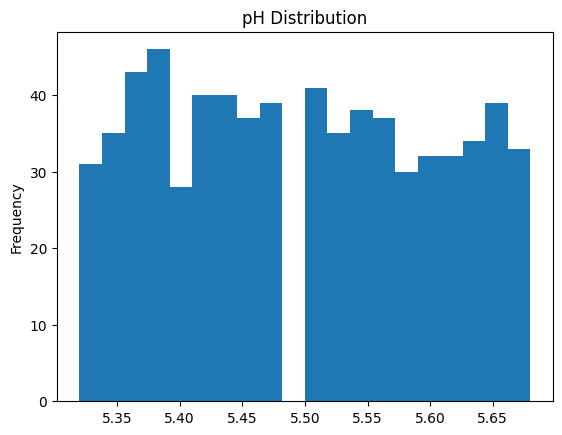

In [ ]:
# Step 4: Perform EDA and Visualizations
# Distribution of 'pH'
plt.figure()
df['pH'].plot(kind='hist', bins=20, title='pH Distribution')
plt.show()

<Figure size 640x480 with 0 Axes>

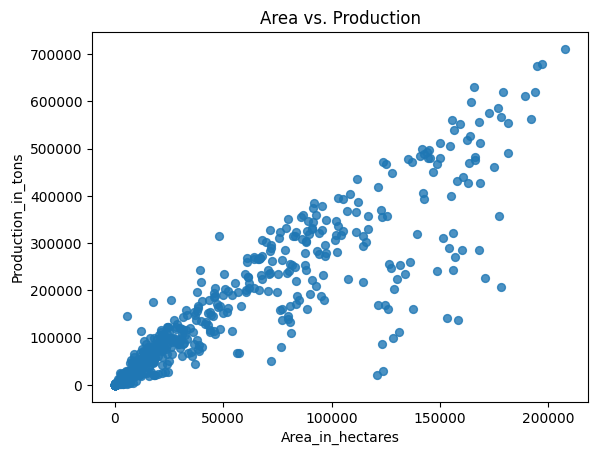

In [ ]:
# Scatter plot between 'Area_in_hectares' and 'Production_in_tons'
plt.figure()
df.plot(kind='scatter', x='Area_in_hectares', y='Production_in_tons', s=32, alpha=0.8, title='Area vs. Production')
plt.show()

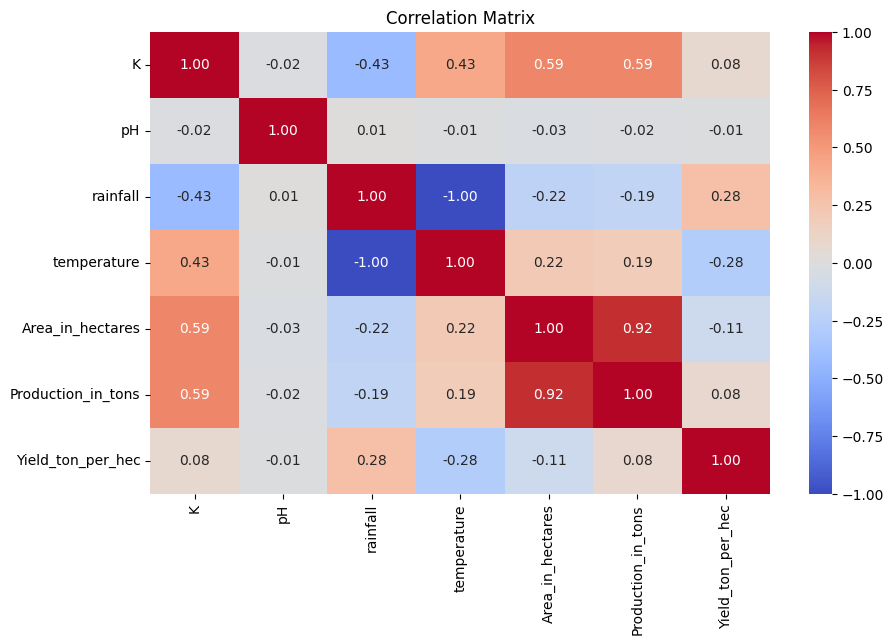

In [ ]:
# Correlation matrix for numerical columns

# Select numerical columns from the dataset
data_numeric = df.select_dtypes(include=['number'])

# Drop 'N' and 'P' columns for the correlation matrix
data_numeric_filtered = data_numeric.drop(columns=['N', 'P'], errors='ignore')

# Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(data_numeric_filtered.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Step 5: Split data into training and testing sets
X = df[['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Area_in_hectares', 'Yield_ton_per_hec']]
y = df['Production_in_tons']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define models
models = {
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'LightGBM Regressor': LGBMRegressor(),
    'Ridge Regression': Ridge()
}

In [ ]:
# Dictionary to store results
results = {}

In [ ]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)  # Train the model
    y_pred = model.predict(X_test_scaled)  # Predict on the test set

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Store results
    results[name] = {
        'R² Score': r2,
        'MAE': mae,
        'MSE': mse
    }

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 414, number of used features: 6
[LightGBM] [Info] Start training from score 112093.741546
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [ ]:
# Find the best model based on R² Score
best_model = max(results, key=lambda x: results[x]['R² Score'])

In [ ]:
# Print results for all models
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  R² Score: {metrics['R² Score']:.4f}")
    print(f"  Mean Absolute Error (MAE): {metrics['MAE']:.4f}")
    print(f"  Mean Squared Error (MSE): {metrics['MSE']:.4f}")

Gradient Boosting Regressor:
  R² Score: 0.9936
  Mean Absolute Error (MAE): 8337.0417
  Mean Squared Error (MSE): 179411288.8049
K-Neighbors Regressor:
  R² Score: 0.9145
  Mean Absolute Error (MAE): 29978.7507
  Mean Squared Error (MSE): 2390124011.4710
Decision Tree Regressor:
  R² Score: 0.9779
  Mean Absolute Error (MAE): 13753.2464
  Mean Squared Error (MSE): 618426291.1522
LightGBM Regressor:
  R² Score: 0.9825
  Mean Absolute Error (MAE): 11033.8799
  Mean Squared Error (MSE): 488647421.5514
Ridge Regression:
  R² Score: 0.8848
  Mean Absolute Error (MAE): 34994.4350
  Mean Squared Error (MSE): 3222438191.6736


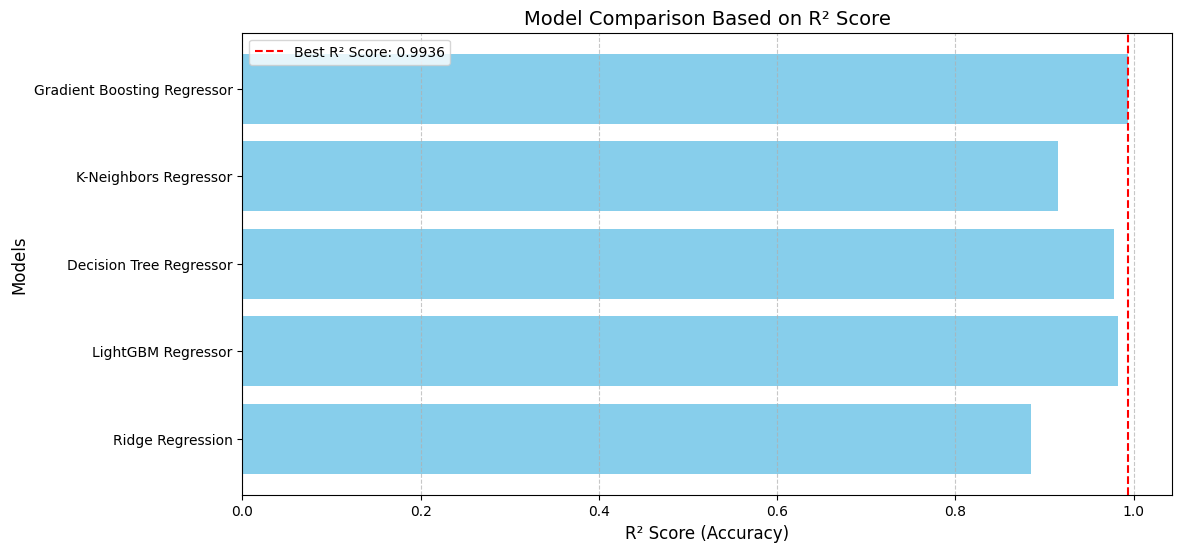

In [ ]:
# Extract model names and their corresponding R² scores from the results dictionary
model_names = list(results.keys())
r2_scores = [metrics['R² Score'] for metrics in results.values()]

# Identify the best model and its R² Score
best_r2_score = max(r2_scores)

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.barh(model_names, r2_scores, color='skyblue')
plt.axvline(best_r2_score, color='red', linestyle='--', label=f"Best R² Score: {best_r2_score:.4f}")
plt.xlabel("R² Score (Accuracy)", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.title("Model Comparison Based on R² Score", fontsize=14)
plt.legend(fontsize=10)
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Step 6: Import and instantiate the Gradient Boosting Regressor
gbr = GradientBoostingRegressor()

# Step 7: Train the model
gbr.fit(X_train_scaled, y_train)

GradientBoostingRegressor()

In [ ]:
# Step 8: Make predictions and display the results
y_pred = gbr.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
accuracy = r2 * 100

print(f"Gradient Boosting Regressor Results:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Gradient Boosting Regressor Results:
R² Score: 0.9936
Mean Absolute Error (MAE): 8344.7952
Mean Squared Error (MSE): 179508207.9458
Accuracy: 99.36%
